####Imports & Setups

In [2]:
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 8.0 MB/s eta 0:00:00


In [1]:
import pandas as pd
import numpy as np
import json
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle

# Embedding & Transformers
import torch
from sentence_transformers import SentenceTransformer
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification

# Clustering & Dimensionality Reduction
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
import hdbscan
import umap

# Topic Modeling
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

# Keyword Extraction
from collections import Counter
from wordcloud import WordCloud
import re

from tqdm.auto import tqdm
tqdm.pandas()

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

####Load Data

In [11]:
main_directory = '/Users/maryam/Downloads/Barnabus Project/'
df = pd.read_csv(f'{main_directory}data/processed/processed_multilingual.csv')
print(f"Loaded data: {df.shape}")

# Load metadata
with open(f'{main_directory}data/processed/processing_metadata.json', 'r') as f:
    metadata = json.load(f)

print("Data summary:")
print(f"   Total samples: {len(df)}")
print(f"   Languages: {df['target_language'].nunique()}")
print(f"   Language distribution:")
for lang, count in df['target_language'].value_counts().items():
    print(f"      {lang}: {count}")

Loaded data: (6000, 7)
Data summary:
   Total samples: 6000
   Languages: 4
   Language distribution:
      de: 1500
      en: 1500
      fr: 1500
      ar: 1500


####Sentence Embeddings

In [5]:
model_name = 'paraphrase-multilingual-MiniLM-L12-v2'
print(f"Loading model: {model_name}")
print("   This model supports 50+ languages including DE, EN, FR, AR")

embedding_model = SentenceTransformer(model_name, device=device)

print("Creating embeddings for all texts...")
print("   This may take a few minutes...")

batch_size = 32
texts_to_embed = df['text_no_stopwords'].fillna('').tolist()

embeddings = embedding_model.encode(
    texts_to_embed,
    batch_size=batch_size,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True  # L2 normalization for better clustering
)

print(f"Created embeddings with shape: {embeddings.shape}")
print(f"   Embedding dimension: {embeddings.shape[1]}")

# Save embeddings
np.save(f'{main_directory}data/embeddings/sentence_embeddings.npy', embeddings)

Loading model: paraphrase-multilingual-MiniLM-L12-v2
   This model supports 50+ languages including DE, EN, FR, AR


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Creating embeddings for all texts...
   This may take a few minutes...


Batches:   0%|          | 0/188 [00:00<?, ?it/s]

Created embeddings with shape: (6000, 384)
   Embedding dimension: 384


####Dimensionality Reduction

In [6]:
# Create 2D projection for visualization
umap_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='cosine',
    random_state=RANDOM_STATE
)
embeddings_2d = umap_2d.fit_transform(embeddings)
print(f"2D projection created: {embeddings_2d.shape}")

# Create 5D projection for clustering (better separation)
umap_5d = umap.UMAP(
    n_components=5,
    n_neighbors=15,
    min_dist=0.0,
    metric='cosine',
    random_state=RANDOM_STATE
)
embeddings_5d = umap_5d.fit_transform(embeddings)
print(f"5D projection created: {embeddings_5d.shape}")

# Save UMAP projections
np.save(f'{main_directory}data/embeddings/umap_2d.npy', embeddings_2d)
np.save(f'{main_directory}data/embeddings/umap_5d.npy', embeddings_5d)

df['umap_x'] = embeddings_2d[:, 0]
df['umap_y'] = embeddings_2d[:, 1]

2D projection created: (6000, 2)
5D projection created: (6000, 5)


####Optimal Cluster Detection

In [7]:
import numpy as np

embeddings_2d = np.load(f'{main_directory}data/embeddings/umap_2d.npy')
embeddings_5d = np.load(f'{main_directory}data/embeddings/umap_5d.npy')

print(embeddings_2d.shape)
print(embeddings_2d[:5])  

(6000, 2)
[[-4.2909007   8.368143  ]
 [-0.6292986   8.140578  ]
 [-3.5002434   9.635873  ]
 [-0.08247284  9.59053   ]
 [-0.28378788  9.8558655 ]]


In [12]:
df['umap_x'] = embeddings_2d[:, 0]
df['umap_y'] = embeddings_2d[:, 1]

In [8]:
k_range = range(5, 21)
silhouette_scores = []
davies_bouldin_scores = []

for k in tqdm(k_range):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(embeddings_5d)

    sil_score = silhouette_score(embeddings_5d, labels)
    db_score = davies_bouldin_score(embeddings_5d, labels)

    silhouette_scores.append(sil_score)
    davies_bouldin_scores.append(db_score)

# Find optimal K (highest silhouette, lowest davies-bouldin)
optimal_k_sil = k_range[np.argmax(silhouette_scores)]
optimal_k_db = k_range[np.argmin(davies_bouldin_scores)]

print(f"Clustering metrics:")
print(f"   Best K by Silhouette Score: {optimal_k_sil} (score: {max(silhouette_scores):.3f})")
print(f"   Best K by Davies-Bouldin: {optimal_k_db} (score: {min(davies_bouldin_scores):.3f})")

# Use average or silhouette preference
optimal_k = optimal_k_sil
print(f"Selected optimal K: {optimal_k}")

# Plot metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, silhouette_scores, marker='o', linewidth=2)
ax1.axvline(optimal_k_sil, color='red', linestyle='--', label=f'Optimal K={optimal_k_sil}')
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Silhouette Score', fontsize=12)
ax1.set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(k_range, davies_bouldin_scores, marker='o', linewidth=2, color='orange')
ax2.axvline(optimal_k_db, color='red', linestyle='--', label=f'Optimal K={optimal_k_db}')
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Davies-Bouldin Index', fontsize=12)
ax2.set_title('Davies-Bouldin Index vs K (lower is better)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig(f'{main_directory}outputs/figures/05_optimal_clusters.png', dpi=300, bbox_inches='tight')
plt.close()

  0%|          | 0/16 [00:00<?, ?it/s]

Clustering metrics:
   Best K by Silhouette Score: 19 (score: 0.397)
   Best K by Davies-Bouldin: 6 (score: 0.845)
Selected optimal K: 19


####KMeans Clustering

In [14]:
kmeans_final = KMeans(n_clusters=optimal_k, random_state=RANDOM_STATE, n_init=20)
df['cluster_kmeans'] = kmeans_final.fit_predict(embeddings_5d)

print(f"K-Means clustering complete")
print(f"Cluster distribution:")
cluster_counts = df['cluster_kmeans'].value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = (count / len(df) * 100)
    print(f"   Cluster {cluster_id}: {count} samples ({pct:.1f}%)")

# Save cluster model
with open(f'{main_directory}models/cache/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

K-Means clustering complete
Cluster distribution:
   Cluster 0: 464 samples (7.7%)
   Cluster 1: 286 samples (4.8%)
   Cluster 2: 415 samples (6.9%)
   Cluster 3: 472 samples (7.9%)
   Cluster 4: 295 samples (4.9%)
   Cluster 5: 374 samples (6.2%)
   Cluster 6: 424 samples (7.1%)
   Cluster 7: 345 samples (5.8%)
   Cluster 8: 342 samples (5.7%)
   Cluster 9: 292 samples (4.9%)
   Cluster 10: 356 samples (5.9%)
   Cluster 11: 133 samples (2.2%)
   Cluster 12: 311 samples (5.2%)
   Cluster 13: 167 samples (2.8%)
   Cluster 14: 292 samples (4.9%)
   Cluster 15: 135 samples (2.2%)
   Cluster 16: 352 samples (5.9%)
   Cluster 17: 240 samples (4.0%)
   Cluster 18: 305 samples (5.1%)


####HBDScan Clustering

In [9]:
hdbscan_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom'
)
df['cluster_hdbscan'] = hdbscan_clusterer.fit_predict(embeddings_5d)

n_clusters_hdb = len(set(df['cluster_hdbscan'])) - (1 if -1 in df['cluster_hdbscan'].values else 0)
n_noise = sum(df['cluster_hdbscan'] == -1)

print(f"HDBSCAN clustering complete")
print(f"   Number of clusters: {n_clusters_hdb}")
print(f"   Noise points: {n_noise} ({n_noise/len(df)*100:.1f}%)")

print(f"HDBSCAN cluster distribution:")
hdb_counts = df['cluster_hdbscan'].value_counts().sort_index()
for cluster_id, count in hdb_counts.items():
    pct = (count / len(df) * 100)
    label = "Noise" if cluster_id == -1 else f"Cluster {cluster_id}"
    print(f"   {label}: {count} samples ({pct:.1f}%)")

# Use K-Means clusters as primary (more balanced)
df['cluster'] = df['cluster_kmeans']

HDBSCAN clustering complete
   Number of clusters: 2
   Noise points: 0 (0.0%)
HDBSCAN cluster distribution:
   Cluster 0: 466 samples (7.8%)
   Cluster 1: 5534 samples (92.2%)


####Visualize Clusters

In [19]:
fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    df['umap_x'],
    df['umap_y'],
    c=df['cluster_kmeans'],
    cmap='tab20',
    alpha=0.6,
    s=20,
    edgecolors='black',
    linewidth=0.5
)
plt.colorbar(scatter, label='Cluster ID')
# ax.set_xlabel('UMAP Dimension 1', fontsize=12)
# ax.set_ylabel('UMAP Dimension 2', fontsize=12)
# ax.set_title(f'K-Means Clustering (K={optimal_k}) on UMAP Projection',
#              fontsize=14, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")  # optional: keep or remove
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Show the plot (optional for display)
# plt.show()

# Save with transparent background
plt.savefig(
    f'{main_directory}outputs/figures/06_kmeans_clusters_umap.png',
    dpi=300,
    bbox_inches='tight',
    transparent=True
)
plt.close()


KeyError: 'cluster_hdbscan'

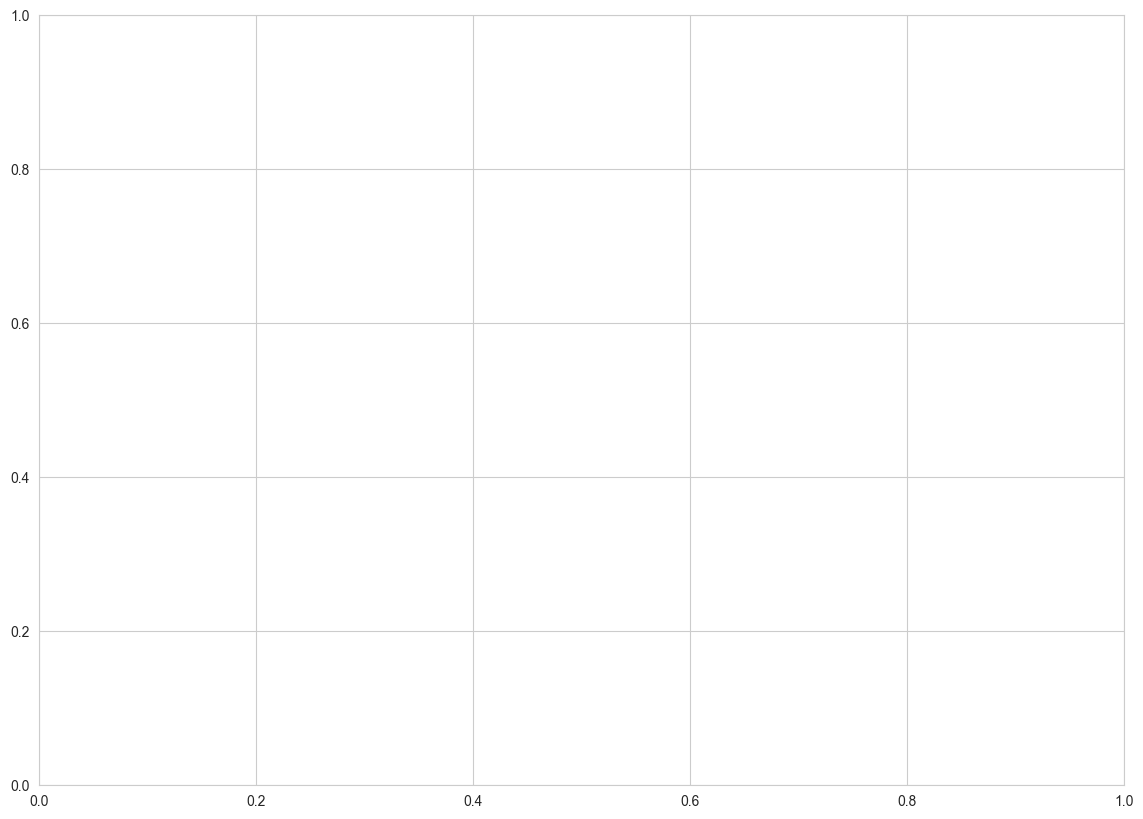

In [18]:
fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    df['umap_x'],
    df['umap_y'],
    c=df['cluster_hdbscan'],
    cmap='tab20',
    alpha=0.6,
    s=20,
    edgecolors='black',
    linewidth=0.5
)
plt.colorbar(scatter, label='Cluster ID (-1 = Noise)')
# ax.set_xlabel('UMAP Dimension 1', fontsize=12)
# ax.set_ylabel('UMAP Dimension 2', fontsize=12)
# ax.set_title('HDBSCAN Clustering on UMAP Projection',
#              fontsize=14, fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")  # optional: keep or remove
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig(f'{main_directory}outputs/figures/07_hdbscan_clusters_umap.png', dpi=300, bbox_inches='tight')
plt.close()

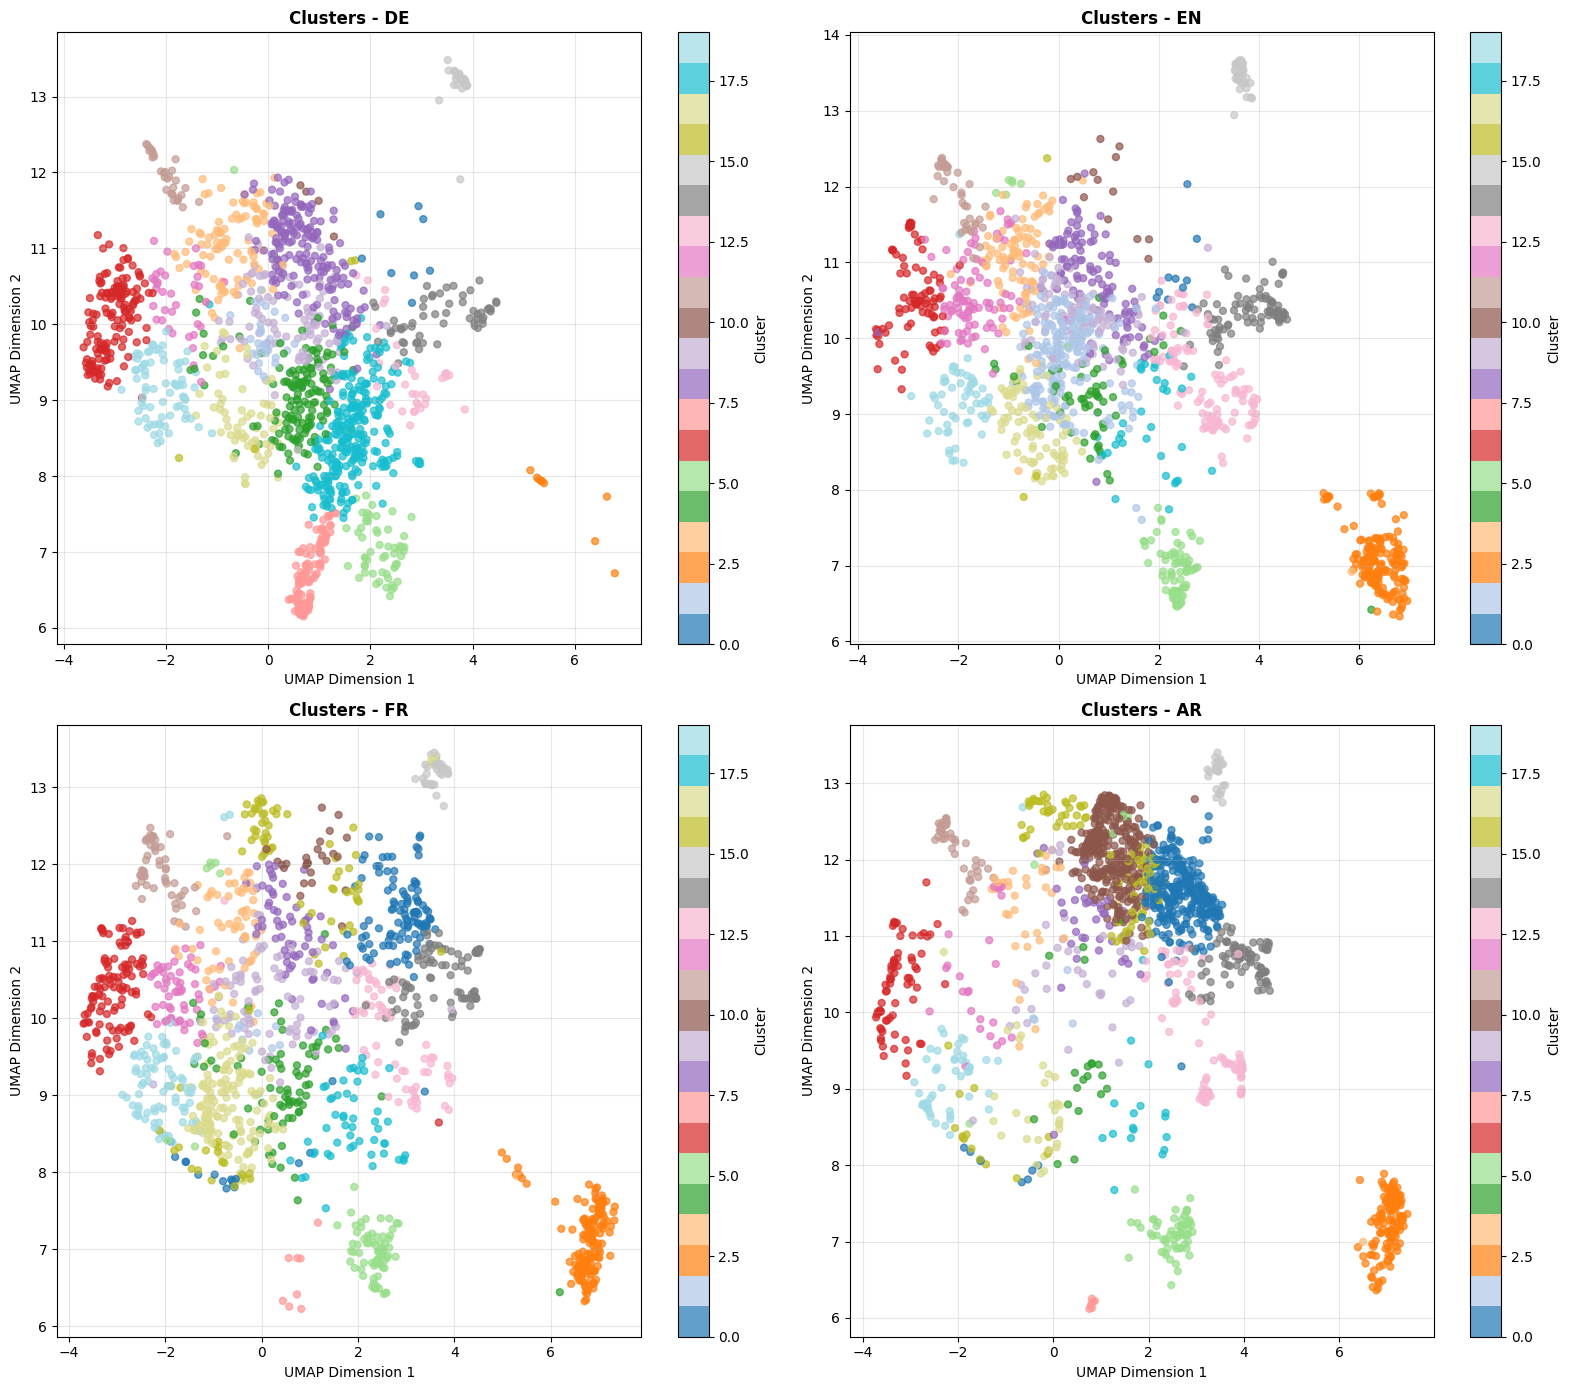

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, lang in enumerate(['de', 'en', 'fr', 'ar']):
    df_lang = df[df['target_language'] == lang]
    scatter = axes[idx].scatter(
        df_lang['umap_x'],
        df_lang['umap_y'],
        c=df_lang['cluster'],
        cmap='tab20',
        alpha=0.7,
        s=25
    )
    axes[idx].set_title(f'Clusters - {lang.upper()}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('UMAP Dimension 1')
    axes[idx].set_ylabel('UMAP Dimension 2')
    axes[idx].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[idx], label='Cluster')

plt.tight_layout()
plt.show()
plt.savefig(f'{main_directory}outputs/figures/08_clusters_by_language.png', dpi=300, bbox_inches='tight')
plt.close()

####Sentiment Analysis

In [15]:
sentiment_model_name = "cardiffnlp/twitter-xlm-roberta-base-sentiment"
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model=sentiment_model_name,
    device=0 if device == "cuda" else -1,
    max_length=512,
    truncation=True
)

config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


In [16]:
def analyze_sentiment_batch(texts, batch_size=16):
    """Analyze sentiment in batches"""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Analyzing sentiment"):
        batch = texts[i:i+batch_size]
        batch_results = sentiment_pipeline(batch)
        results.extend(batch_results)
    return results

In [17]:
texts_for_sentiment = df['text_final'].fillna('').tolist()
sentiment_results = analyze_sentiment_batch(texts_for_sentiment, batch_size=16)

# Extract sentiment labels and scores
df['sentiment_label'] = [r['label'] for r in sentiment_results]
df['sentiment_score'] = [r['score'] for r in sentiment_results]

Analyzing sentiment:   0%|          | 0/375 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [18]:
sentiment_mapping = {
    'Negative': 'negative',
    'Neutral': 'neutral',
    'Positive': 'positive',
    'NEGATIVE': 'negative',
    'NEUTRAL': 'neutral',
    'POSITIVE': 'positive',
    'negative': 'negative',
    'neutral': 'neutral',
    'positive': 'positive',
    'LABEL_0': 'negative',  # Some models use numeric labels
    'LABEL_1': 'neutral',
    'LABEL_2': 'positive'
}
df['sentiment'] = df['sentiment_label'].map(sentiment_mapping)

In [19]:
sent_counts = df['sentiment'].value_counts()
for sent, count in sent_counts.items():
    pct = (count / len(df) * 100)
    print(f"   {sent}: {count} ({pct:.1f}%)")

   positive: 4204 (70.1%)
   negative: 1267 (21.1%)
   neutral: 529 (8.8%)


####Rating-Based Sentiment

In [20]:
if 'rating_normalized' in df.columns and df['rating_normalized'].notna().sum() > 0:
    df['sentiment_from_rating'] = pd.cut(
        df['rating_normalized'],
        bins=[0, 2.5, 3.5, 5],
        labels=['negative', 'neutral', 'positive']
    )

    comparison = pd.crosstab(
        df['sentiment'],
        df['sentiment_from_rating'],
        normalize='index'
    ) * 100

    print("Sentiment Model vs Rating Agreement (%):")
    print(comparison.round(1))

    agreement = (df['sentiment'] == df['sentiment_from_rating']).sum()
    agreement_pct = (agreement / len(df[df['sentiment_from_rating'].notna()]) * 100)

Sentiment Model vs Rating Agreement (%):
sentiment_from_rating  negative  neutral  positive
sentiment                                         
negative                   52.8     11.2      36.0
neutral                    83.6      4.7      11.7
positive                   99.3      0.1       0.6


####Keyword Extraction Per Cluster

In [21]:
def extract_keywords(texts, top_n=10):
    """Extract most common keywords from a list of texts"""
    all_words = []
    for text in texts:
        if pd.notna(text) and text != '':
            words = re.findall(r'\b\w+\b', text.lower())
            words = [w for w in words if len(w) > 3 and not w.isdigit()]
            all_words.extend(words)

    word_counts = Counter(all_words)
    return word_counts.most_common(top_n)

In [22]:
cluster_keywords = {}
cluster_info = []

for cluster_id in sorted(df['cluster'].unique()):
    cluster_texts = df[df['cluster'] == cluster_id]['text_no_stopwords'].tolist()
    keywords = extract_keywords(cluster_texts, top_n=15)
    cluster_keywords[cluster_id] = keywords

    cluster_size = len(cluster_texts)
    cluster_sentiment = df[df['cluster'] == cluster_id]['sentiment'].value_counts().to_dict()

    cluster_info.append({
        'cluster_id': cluster_id,
        'size': cluster_size,
        'percentage': f"{(cluster_size/len(df)*100):.1f}%",
        'keywords': [kw[0] for kw in keywords[:10]],
        'sentiment_distribution': cluster_sentiment
    })

    print(f"Cluster {cluster_id} ({cluster_size} samples):")
    print(f"   Top keywords: {', '.join([kw[0] for kw in keywords[:10]])}")
    print(f"   Sentiment: {cluster_sentiment}")

cluster_info_df = pd.DataFrame(cluster_info)
cluster_info_df.to_csv(f'{main_directory}outputs/cluster_info.csv', index=False)

Cluster 0 (440 samples):
   Top keywords: للغاية, الدكتور, العلاج, الطبيب, الانتظار, كانت, بشكل, très, الممارسة, الوقت
   Sentiment: {'positive': 208, 'negative': 167, 'neutral': 65}
Cluster 1 (276 samples):
   Top keywords: practice, time, always, good, friendly, treatment, also, waiting, takes, patients
   Sentiment: {'positive': 197, 'negative': 61, 'neutral': 18}
Cluster 2 (466 samples):
   Top keywords: très, الأسنان, dentist, practice, dentiste, treatment, cabinet, traitement, للغاية, الدكتور
   Sentiment: {'positive': 368, 'negative': 73, 'neutral': 25}
Cluster 3 (287 samples):
   Top keywords: très, team, practice, friendly, patients, competent, équipe, treatment, nice, good
   Sentiment: {'positive': 274, 'negative': 7, 'neutral': 6}
Cluster 4 (305 samples):
   Top keywords: behandlung, très, patienten, zeit, immer, patients, tout, wurde, temps, nimmt
   Sentiment: {'positive': 150, 'negative': 128, 'neutral': 27}
Cluster 5 (291 samples):
   Top keywords: très, enfants, toujou

####Sentiment Distribution Per Cluster

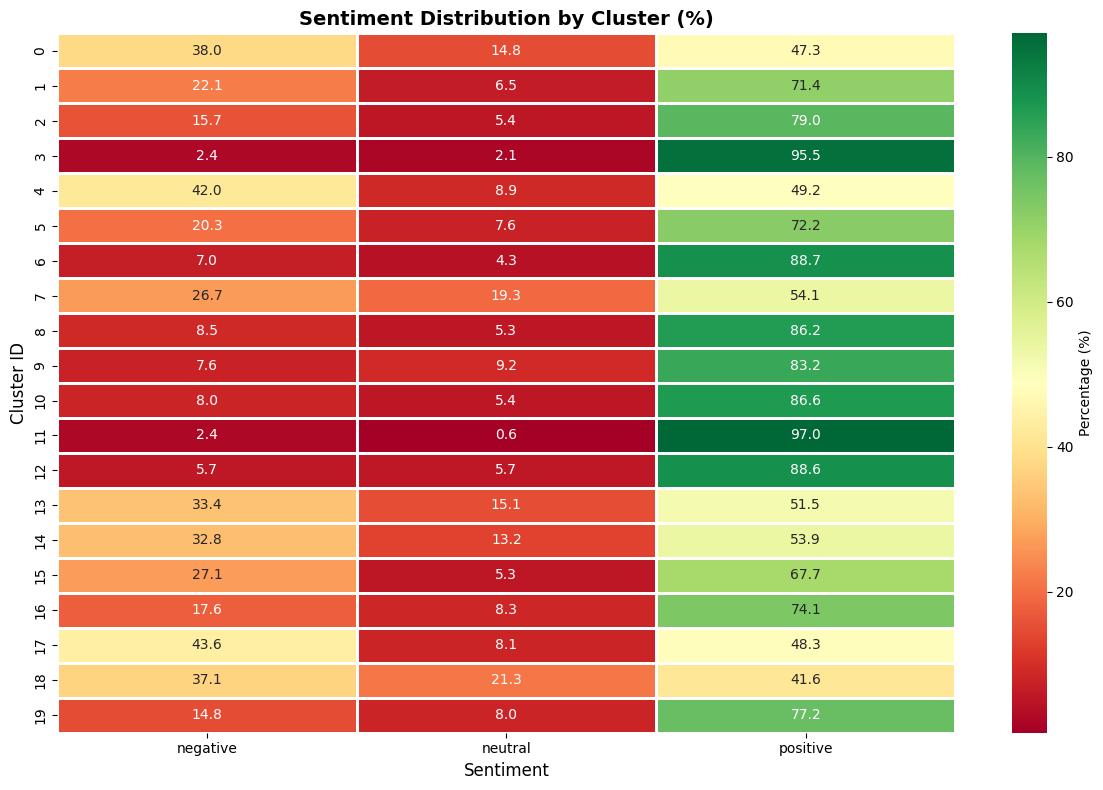

Cluster Sentiment Analysis:

Cluster 0:
   Dominant sentiment: positive (47.3%)
   Distribution: negative: 38.0% | neutral: 14.8% | positive: 47.3%

Cluster 1:
   Dominant sentiment: positive (71.4%)
   Distribution: negative: 22.1% | neutral: 6.5% | positive: 71.4%

Cluster 2:
   Dominant sentiment: positive (79.0%)
   Distribution: negative: 15.7% | neutral: 5.4% | positive: 79.0%

Cluster 3:
   Dominant sentiment: positive (95.5%)
   Distribution: negative: 2.4% | neutral: 2.1% | positive: 95.5%

Cluster 4:
   Dominant sentiment: positive (49.2%)
   Distribution: negative: 42.0% | neutral: 8.9% | positive: 49.2%

Cluster 5:
   Dominant sentiment: positive (72.2%)
   Distribution: negative: 20.3% | neutral: 7.6% | positive: 72.2%

Cluster 6:
   Dominant sentiment: positive (88.7%)
   Distribution: negative: 7.0% | neutral: 4.3% | positive: 88.7%

Cluster 7:
   Dominant sentiment: positive (54.1%)
   Distribution: negative: 26.7% | neutral: 19.3% | positive: 54.1%

Cluster 8:
   Domin

In [24]:
sentiment_by_cluster = pd.crosstab(
    df['cluster'],
    df['sentiment'],
    normalize='index'
) * 100

plt.figure(figsize=(12, 8))
sns.heatmap(
    sentiment_by_cluster,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn',
    cbar_kws={'label': 'Percentage (%)'},
    linewidths=1
)
plt.title('Sentiment Distribution by Cluster (%)', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Cluster ID', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig(f'{main_directory}outputs/figures/10_sentiment_by_cluster.png', dpi=300, bbox_inches='tight')
plt.close()

print("Cluster Sentiment Analysis:")
for cluster_id in sorted(df['cluster'].unique()):
    cluster_sent = sentiment_by_cluster.loc[cluster_id]
    dominant_sent = cluster_sent.idxmax()
    dominant_pct = cluster_sent.max()

    print(f"\nCluster {cluster_id}:")
    print(f"   Dominant sentiment: {dominant_sent} ({dominant_pct:.1f}%)")
    print(f"   Distribution: " + " | ".join([f"{s}: {cluster_sent[s]:.1f}%" for s in cluster_sent.index]))


####Save Final Data

In [26]:
df.to_csv(f'{main_directory}data/processed/analyzed_data.csv', index=False)

embeddings_metadata = {
    'model_name': model_name,
    'embedding_dim': embeddings.shape[1],
    'n_samples': embeddings.shape[0],
    'optimal_k': optimal_k,
    'n_clusters_kmeans': optimal_k,
    'n_clusters_hdbscan': n_clusters_hdb,
    'sentiment_model': sentiment_model_name
}

with open(f'{main_directory}data/embeddings/embeddings_metadata.json', 'w') as f:
    json.dump(embeddings_metadata, f, indent=2)
print("✓ Saved embeddings metadata")

print("PHASE 3 COMPLETE: NLP ANALYSIS DONE")
print("\nKey outputs:")
print("1. Sentence embeddings created")
print("2. Optimal clustering performed")
print("3. Sentiment analysis completed")
print("4. Keywords extracted per cluster")
print("5. Visualizations generated")
print("\nNext steps:")
print("1. Review outputs/figures/ for all visualizations")
print("2. Proceed to 04_llm_summarization.ipynb for LLM summaries")
print("3. Then build recommendation engine")

✓ Saved embeddings metadata
PHASE 3 COMPLETE: NLP ANALYSIS DONE

Key outputs:
1. Sentence embeddings created
2. Optimal clustering performed
3. Sentiment analysis completed
4. Keywords extracted per cluster
5. Visualizations generated

Next steps:
1. Review outputs/figures/ for all visualizations
2. Proceed to 04_llm_summarization.ipynb for LLM summaries
3. Then build recommendation engine
